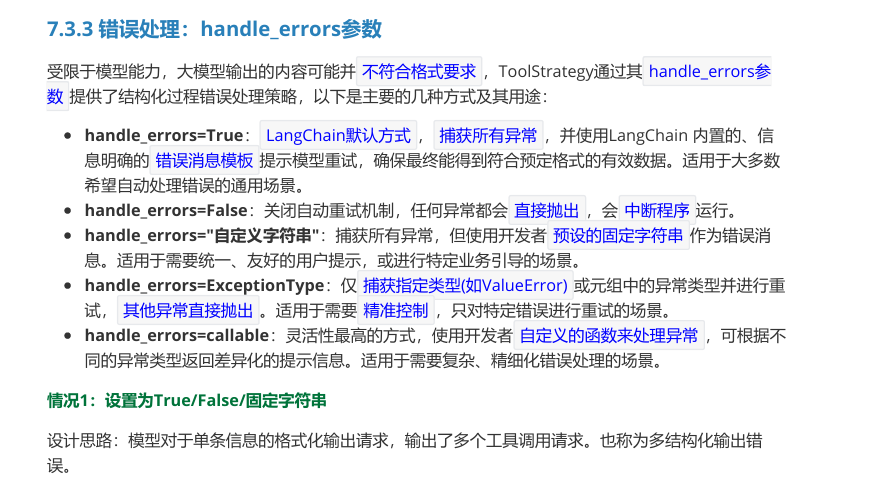
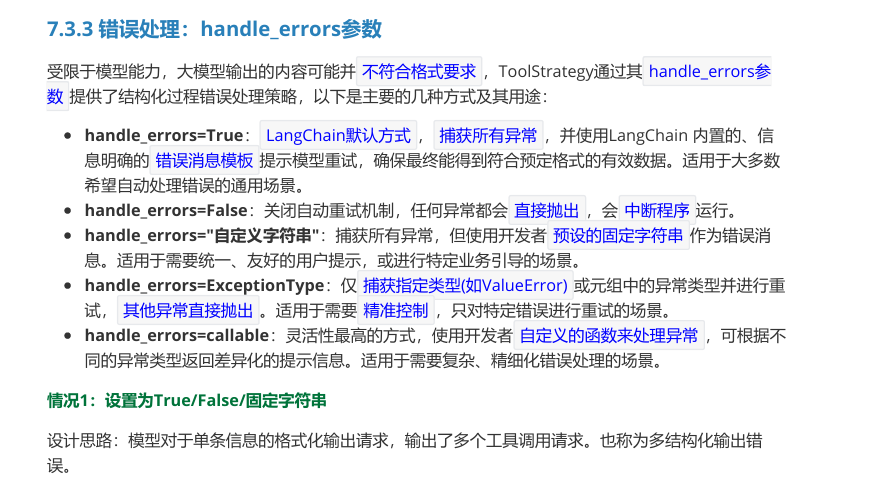

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}}  #关闭思考模式
)


案例1 演示错误处理机制

In [3]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from rich import print as rprint


class ContactInfo(BaseModel):
    """个人联系信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="电子邮箱")


class EventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")


"""
案例1 演示错误处理机制
    handle_errors=True  # 开启错误处理 会使用LangChain内置的错误提示词模板进行重试  模型接收到错误反馈后，再次生成新的调用请求，直至成功或达到内部的最大重试次数。
                            ToolStrategy中自定义的tool_message_content控制的是成功后的消息内容，不影响错误消息内容。
    handle_errors=False  # 关闭错误处理 不会进行重试 直接抛出异常
    handle_errors="请检查输入数据"  # 会使用自定义的错误提示词进行重试
"""
agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EventDetails],
        tool_message_content="提取完成！",
        handle_errors=True
        #handle_errors="请检查输入数据"
    )
)
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": f"请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：2026-07-15"
    }]
})
rprint(result)
for msg in result["messages"]:
    msg.pretty_print()
#
# report_data = result["structured_response"]
# print(report_data)

{
    'messages': [
        HumanMessage(
            content='请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：
2026-07-15',
            additional_kwargs={},
            response_metadata={},
            id='84f5b432-07f6-4769-af61-9b8fb2adfe22'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 112,
                    'prompt_tokens': 410,
                    'total_tokens': 522,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                    'prompt_cache_hit_tokens': 384,
                    'prompt_cache_miss_tokens': 26
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'add7d693-b777-4c99-80a6-c72c6248868c',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69cd-d74d-7533-8cdf-6d5cdd232142-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_00_banIsZmXzEanVeUXGSAG9011',
                    'type': 'tool_call'
                },
                {
                    'name': 'EventDetails',
                    'args': {'event_name': '公司年会', 'date': '2026-07-15'},
                    'id': 'call_01_fQWmMrpMOLAerNOYt8wJ9009',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 410,
                'output_tokens': 112,
                'total_tokens': 522,
                'input_token_details': {'cache_read': 384},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='ContactInfo',
            id='cdf5cd95-8cb4-4c78-914b-e4493c2f357f',
            tool_call_id='call_00_banIsZmXzEanVeUXGSAG9011'
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='EventDetails',
            id='e05f6a67-3d52-4b46-b57c-4504df365042',
            tool_call_id='call_01_fQWmMrpMOLAerNOYt8wJ9009'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 59,
                    'prompt_tokens': 599,
                    'total_tokens': 658,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                    'prompt_cache_hit_tokens': 512,
                    'prompt_cache_miss_tokens': 87
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '024841e8-f36e-407c-a34e-8b27fe370a6a',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69cd-dc8d-7c61-9d0d-4bc82d1df14d-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_00_mpyjxE1GdkwhxrsefVI20084',
                    'type': 'tool_call

================================ Human Message =================================

请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：2026-07-15
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_00_banIsZmXzEanVeUXGSAG9011)
 Call ID: call_00_banIsZmXzEanVeUXGSAG9011
  Args:
    name: 张三
    email: zhang3@atguigu.com
  EventDetails (call_01_fQWmMrpMOLAerNOYt8wJ9009)
 Call ID: call_01_fQWmMrpMOLAerNOYt8wJ9009
  Args:
    event_name: 公司年会
    date: 2026-07-15
================================= Tool Message =================================
Name: ContactInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) when only one is expected.
 Please fix your mistakes.
================================= Tool Message =================================
Name: EventDetails

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) when only one is expected.
 Pleas

以上代码中注意如下几点：
1. ToolStrategy允许指定多个类型“Union[ContactInfo, EventDetails]”这种写法，但是最终只会转换
成一种结构化类型输出。
2. 当ToolStrategy通过“Union[ContactInfo, EventDetails]”指定多个类型时，在内部调用生成结构化
类型工具会报错。此时：
handle_errors=True（默认值）开始发挥作用，系统会生成一个ToolMessage，明确告诉
LLM“Error: Model incorrectly returned multiple structured responses (ContactInfo,
EventDetails) when only one is expected.”，大模型收到这个精准的反馈后，会重新进行推
理，最终选择并输出一个最符合要求的Schema。
如果handle_errors 设置为False，执行代码过程直接报错。
3. 当格式化输出有错误时，Agent内部会进行工具调用重试，直到符合要求格式化输出前，
行多次重试

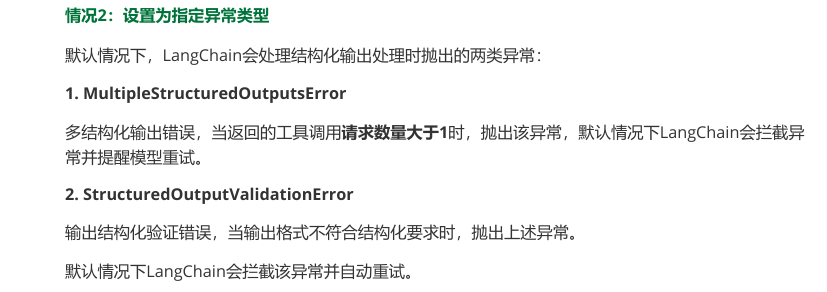

In [4]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy, MultipleStructuredOutputsError, \
    StructuredOutputValidationError

StructuredOutputValidationError,
MultipleStructuredOutputsError
from rich import print as rprint


class ContactInfo(BaseModel):
    """个人联系信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="电子邮箱")


class EventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")


agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EventDetails],
        tool_message_content="提取完成！",
        handle_errors=(MultipleStructuredOutputsError, StructuredOutputValidationError)
        # handle_errors=(StructuredOutputValidationError)
    )
)
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": f"请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：2026-07-15"
    }]
})
rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：
2026-07-15',
            additional_kwargs={},
            response_metadata={},
            id='906f705c-68b4-4478-9650-a7cfb050d7d9'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 112,
                    'prompt_tokens': 410,
                    'total_tokens': 522,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                    'prompt_cache_hit_tokens': 384,
                    'prompt_cache_miss_tokens': 26
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '8196404c-9411-4d4e-bb09-9be998401cd3',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69cf-5471-7301-8459-5038a2f15915-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_00_9sdTqNUTuFJSJS04BAQB9494',
                    'type': 'tool_call'
                },
                {
                    'name': 'EventDetails',
                    'args': {'event_name': '公司年会', 'date': '2026-07-15'},
                    'id': 'call_01_YQ1tRRn7IqhvtBD9XXu48500',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 410,
                'output_tokens': 112,
                'total_tokens': 522,
                'input_token_details': {'cache_read': 384},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='ContactInfo',
            id='b8c03a24-9317-4e10-b683-e7bab0f88ded',
            tool_call_id='call_00_9sdTqNUTuFJSJS04BAQB9494'
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='EventDetails',
            id='efc1fb89-ed78-455e-8a69-36bfc103527c',
            tool_call_id='call_01_YQ1tRRn7IqhvtBD9XXu48500'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 59,
                    'prompt_tokens': 599,
                    'total_tokens': 658,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                    'prompt_cache_hit_tokens': 512,
                    'prompt_cache_miss_tokens': 87
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'c0cad43b-bbb4-4418-80c4-ed8861f23831',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69cf-5b25-7903-85e4-eb68148500c8-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_00_Sm58a9vKXaQt6TM3mXFE2537',
                    'type': 'tool_call

情况3：设置为自定义错误处理函数
指定异常处理函数并返回字符串时，LangChain会在遇到异常时自动重试并将异常处理函数的返回值作
为ToolMessage的内容。
我们也可以选择在异常处理函数中抛出异常。

In [5]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy, StructuredOutputValidationError, \
    MultipleStructuredOutputsError
from rich import print as rprint


# 自定义错误处理函数
def custom_error_handler(error: Exception) -> str:
    """自定义错误处理器"""
    error_str = str(error)
    print(f"捕获到错误类型：{type(error).__name__}")
    print(f"错误详情：{error_str}")
    if isinstance(error, StructuredOutputValidationError):
        return "数据格式有误，请检查字段是否符合要求。"
    elif isinstance(error, MultipleStructuredOutputsError):
        return "检测到多个响应，请选择最相关的一个进行返回。"
    else:
        return f"Error: {error_str}"


class ContactInfo(BaseModel):
    """个人联系信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="电子邮箱")


class EventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")


agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EventDetails],
        tool_message_content="提取完成！",
        handle_errors=custom_error_handler
    )
)
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": f"请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：2026-07-15"
    }]
})
rprint(result)

捕获到错误类型：MultipleStructuredOutputsError
错误详情：Model incorrectly returned multiple structured responses (ContactInfo, EventDetails) when only one is expected.


{
    'messages': [
        HumanMessage(
            content='请提取以下文本中内容：姓名：张三，电子邮箱：zhang3@atguigu.com，活动名称：公司年会，活动日期：
2026-07-15',
            additional_kwargs={},
            response_metadata={},
            id='69931e4f-cb58-4b57-b4b4-cdf33dcfa594'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 112,
                    'prompt_tokens': 410,
                    'total_tokens': 522,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                    'prompt_cache_hit_tokens': 384,
                    'prompt_cache_miss_tokens': 26
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'd7774e2f-7be6-4a6c-b398-21a16a7fd243',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69d3-15a2-7303-bef9-ae9affc93e51-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_00_BD3ya2l27eqSLV1QU8Dh7719',
                    'type': 'tool_call'
                },
                {
                    'name': 'EventDetails',
                    'args': {'event_name': '公司年会', 'date': '2026-07-15'},
                    'id': 'call_01_8DzsL6maIpHM5HrR3Zlu6545',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 410,
                'output_tokens': 112,
                'total_tokens': 522,
                'input_token_details': {'cache_read': 384},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='检测到多个响应，请选择最相关的一个进行返回。',
            name='ContactInfo',
            id='36aeb788-ee13-4d0e-af81-02b363dcc897',
            tool_call_id='call_00_BD3ya2l27eqSLV1QU8Dh7719'
        ),
        ToolMessage(
            content='检测到多个响应，请选择最相关的一个进行返回。',
            name='EventDetails',
            id='9adce4a2-bdf2-465e-a05d-a4caa0a19dfc',
            tool_call_id='call_01_8DzsL6maIpHM5HrR3Zlu6545'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 59,
                    'prompt_tokens': 573,
                    'total_tokens': 632,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                    'prompt_cache_hit_tokens': 512,
                    'prompt_cache_miss_tokens': 61
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '428b8c98-9203-4723-8b50-54d6497c73c1',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69d3-1ba4-7652-87e6-c5d4afe242e7-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_00_NYyjjtcsbBXyI8LSUD6c1732',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 573,
                'output_tokens': 59,
                'total_tokens': 632,
                'input_token_details': {